In [ ]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(0)

In [ ]:
import os
import json
from zipfile import ZipFile
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import imagesize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
!pip install imagesize

In [ ]:
!pip install kagglehub

In [ ]:
kaggle_credintials = json.load(open("kaggle.json"))

In [ ]:
#setup kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credintials['username']
os.environ['KAGGLE_KEY'] = kaggle_credintials['key']

In [ ]:
#!/bin/bash
!kaggle datasets download abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
 99% 2.02G/2.04G [00:10<00:00, 257MB/s]
100% 2.04G/2.04G [00:10<00:00, 215MB/s]


In [ ]:
!ls

kaggle.json  plantvillage-dataset.zip  sample_data


In [ ]:
#UNZIPPING
from zipfile import ZipFile
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
  zip_ref.extractall()

In [ ]:
print(os.listdir("plantvillage dataset"))

print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented/")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color/")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale/")[:5])

['color', 'grayscale', 'segmented']
38
['Apple___Black_rot', 'Cherry_(including_sour)___healthy', 'Apple___Apple_scab', 'Pepper,_bell___healthy', 'Pepper,_bell___Bacterial_spot']
38
['Apple___Black_rot', 'Cherry_(including_sour)___healthy', 'Apple___Apple_scab', 'Pepper,_bell___healthy', 'Pepper,_bell___Bacterial_spot']
38
['Apple___Black_rot', 'Cherry_(including_sour)___healthy', 'Apple___Apple_scab', 'Pepper,_bell___healthy', 'Pepper,_bell___Bacterial_spot']


In [ ]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

(256, 256, 3)


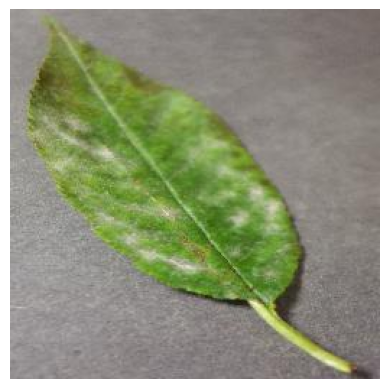

In [ ]:
image_path = '/content/plantvillage dataset/color/Cherry_(including_sour)___Powdery_mildew/00b7df55-c789-43d6-a02e-a579ac9d07e6___FREC_Pwd.M 4748.JPG'

#Read the image
img = mpimg.imread(image_path)

print(img.shape)
#display the image
plt.imshow(img)
plt.axis('off') # Turn off axis number
plt.show()

In [ ]:
#Image Parameters
img_size = 234
batch_size = 32

In [ ]:
# image data generator
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 #usiing 20% data for validation
)

In [ ]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 43456 images belonging to 38 classes.


In [ ]:
# Validation Generator
Validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 10849 images belonging to 38 classes.


**Convulation Neural Network**

In [ ]:
# Model defination
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# model summery
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 232, 232, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 116, 116, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 114, 114, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 57, 57, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 55, 55, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    23,888,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,991,142 (91.52 MB)

 Trainable params: 23,991,142 (91.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**MODEL TRAINING**

In [ ]:
# Training the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size, # Number of steps per epoch
    epochs=5, #Number of epochs
    validation_data=Validation_generator,
    validation_steps=Validation_generator.samples // batch_size # Validation steps

)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 107s 73ms/step - accuracy: 0.5811 - loss: 1.5575 - val_accuracy: 0.8609 - val_loss: 0.4388
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 140s 103ms/step - accuracy: 0.8976 - loss: 0.3175 - val_accuracy: 0.8889 - val_loss: 0.3476
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 100s 72ms/step - accuracy: 0.9502 - loss: 0.1524 - val_accuracy: 0.8955 - val_loss: 0.3520
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 99s 73ms/step - accuracy: 0.9705 - loss: 0.0887 - val_accuracy: 0.9004 - val_loss: 0.3851
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 141s 72ms/step - accuracy: 0.9748 - loss: 0.0816 - val_accuracy: 0.9014 - val_loss: 0.3800


MODEL EVALUATION

In [ ]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(Validation_generator, steps=Validation_generator.samples // batch_size)
print(f"Validation accuracy: {val_accuracy* 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.8956 - loss: 0.3951
Validation accuracy: 90.15%


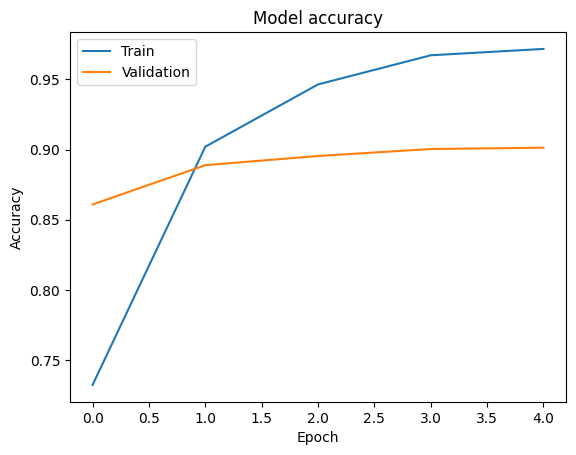

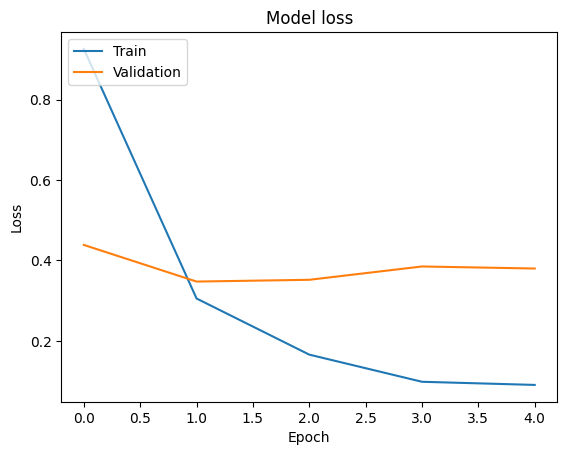

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

BUILDING A PREDICTIVE SYSTEM

In [ ]:
# Function to Load and Preprocess the Image Using Pillow
def load_and_preprocess_Image(image_path,target_size=(234,234)):
  #Load the image
  img = Image.open(image_path)
  # Resize the Image
  img = img.resize(target_size)
  # Convert the image to a numpy array
  img_array = np.array(img)
  # Add batch discussion
  img_array = np.expand_dims(img_array, axis=0)
  # Scale the image values to (0,1)
  img_array = img_array.astype('float32') / 255.
  return img_array

# Function to predict the class of an image
def predict_image_class(model,image_path,class_indices):
    preprocessed_image = load_and_preprocess_Image(image_path)
    prediction = model.predict(preprocessed_image)
    predicted_class_index = np.argmax(prediction, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
# create a mapping from clas indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [ ]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [ ]:
# Saving the class names as json file
json.dump(class_indices, open("class_indices.json", "w"))

In [ ]:
#Example Usage
image_path = '/content/plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG'
#image_path = '/content/test_blueberry_healthy.jpg'
#image_path = '/content/test_potato_early_blight.jpg'
predicted_class_name = predict_image_class(model,image_path, class_indices)

#Output the result
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class Name: Pepper,_bell___healthy


In [1]:
!git config --global user.name "satyamr814"

In [2]:
!git config --global user.email "satyamr814@gmail.com"

In [4]:
%cd /content
!git clone https://github.com/satyamr814/Plant-Disease-Detection-
%cd Plant-Disease-Detection

/content
Cloning into 'Plant-Disease-Detection-'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
Receiving objects: 100% (8/8), 4.07 KiB | 4.07 MiB/s, done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
[Errno 2] No such file or directory: 'Plant-Disease-Detection'
/content


In [6]:
!cp -r /content/* /content/Plant-Disease-Detection-/

cp: cannot copy a directory, '/content/Plant-Disease-Detection-', into itself, '/content/Plant-Disease-Detection-/Plant-Disease-Detection-'


In [7]:
!git add .
!git commit -m "Added Plant Disease Detection CNN Model"
!git push -u origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [13]:
%cd /content/Plant-Disease-Detection-

/content/Plant-Disease-Detection-


In [14]:
# Copy the saved model and class indices to the cloned repository
!cp /content/plant_disease_model.h5 .
!cp /content/class_indices.json .

cp: cannot stat '/content/plant_disease_model.h5': No such file or directory
cp: cannot stat '/content/class_indices.json': No such file or directory


In [15]:
!git add .
!git commit -m "Added Plant Disease Detection CNN Model and class indices"
!git branch -M main
!git push -u origin main

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
  (commit or discard the untracked or modified content in submodules)
	modified:   Plant-Disease-Detection- (untracked content)

no changes added to commit (use "git add" and/or "git commit -a")
fatal: could not read Username for 'https://github.com': No such device or address
